first import necessary modules

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
df_si = pd.read_csv("spec_RBCL_16s.csv", low_memory=False)
df_si.head()

,UniqueID,TempID,EventID,Collector,Apidae,AspergillusSpp,AscosphaeraSpp,ApicystisSpp,CrithidiaExpoeki,CrithidiaBombi,...,RBCL:Scrophulariaceae_Verbascum_thapsus,RBCL:Fabaceae_Dalea_polygonoides,RBCL:Brassicaceae_Capsella__bursa-pastoris,RBCL:Fabaceae_Trifolium_sp._A,RBCL:Scrophulariaceae_Scrophularia_sp._A,RBCL:Rosaceae_Sanguisorba_sp._A,RBCL:Brassicaceae_Sisymbrium_sp._A,RBCL:Rosaceae_Rubus__sp._A,RBCL:Geraniaceae_Geranium__sp._A,RBCL:Apiaceae_Unknown_sp._M
0,17648,17648,NaN,PM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17649,17649,NaN,PM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17650,17650,NaN,PM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,17653,17653,NaN,PM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17654,17654,NaN,PM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


add bee species names to genus in one column

In [3]:
df_si['GenSp'] = df_si['Genus'] + '.' + df_si['Species']
df_si

,UniqueID,TempID,EventID,Collector,Apidae,AspergillusSpp,AscosphaeraSpp,ApicystisSpp,CrithidiaExpoeki,CrithidiaBombi,...,RBCL:Fabaceae_Dalea_polygonoides,RBCL:Brassicaceae_Capsella__bursa-pastoris,RBCL:Fabaceae_Trifolium_sp._A,RBCL:Scrophulariaceae_Scrophularia_sp._A,RBCL:Rosaceae_Sanguisorba_sp._A,RBCL:Brassicaceae_Sisymbrium_sp._A,RBCL:Rosaceae_Rubus__sp._A,RBCL:Geraniaceae_Geranium__sp._A,RBCL:Apiaceae_Unknown_sp._M,GenSp
0,17648,17648,NaN,PM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Heterosarus.bakeri
1,17649,17649,NaN,PM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lasioglossum.ruidosense
2,17650,17650,NaN,PM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Andrena.apacheorum
3,17653,17653,NaN,PM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lasioglossum.ruidosense
4,17654,17654,NaN,PM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Heterosarus.bakeri
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7252,SC_072912_93,2578,NaN,LCP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Eristalis.tenax
7253,SC_072912_94,2579,NaN,LCP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lasioglossum.sisymbrii
7254,SC_072912_95,2580,NaN,LCP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Copestylum.avidum
7255,SC_072912_96,2581,NaN,LCP,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Copestylum.lentum


use list comp to pull out all cols that start with RBCL

In [4]:
rbcl_cols = [col for col in df_si if col.startswith('RBCL')]
my_cols = ['lat_long'] + rbcl_cols

use reindex to fix indexing error

In [5]:
df_si = df_si.reindex(columns=my_cols)
df_si

,lat_long,RBCL:Boraginaceae_Unknown_sp._A,RBCL:Asteraceae_Taraxacum_sp._A,RBCL:Asteraceae_Unknown_sp._E,RBCL:Asteraceae_Laennecia_schiedeana,RBCL:Apiaceae_Unknown_sp._D,RBCL:Apiaceae_Tanacetum__corymbosum,RBCL:Asteraceae_Tanacetum__balsamita,RBCL:Lamiaceae_Agastache_sp._A,RBCL:Asteraceae_Cichorium_intybus,...,RBCL:Scrophulariaceae_Verbascum_thapsus,RBCL:Fabaceae_Dalea_polygonoides,RBCL:Brassicaceae_Capsella__bursa-pastoris,RBCL:Fabaceae_Trifolium_sp._A,RBCL:Scrophulariaceae_Scrophularia_sp._A,RBCL:Rosaceae_Sanguisorba_sp._A,RBCL:Brassicaceae_Sisymbrium_sp._A,RBCL:Rosaceae_Rubus__sp._A,RBCL:Geraniaceae_Geranium__sp._A,RBCL:Apiaceae_Unknown_sp._M
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7253,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7254,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Remove rows of bees that have no data for rbcl

In [6]:
df_si1 = df_si.dropna(subset=[i for i in rbcl_cols])
df_si1

,lat_long,RBCL:Boraginaceae_Unknown_sp._A,RBCL:Asteraceae_Taraxacum_sp._A,RBCL:Asteraceae_Unknown_sp._E,RBCL:Asteraceae_Laennecia_schiedeana,RBCL:Apiaceae_Unknown_sp._D,RBCL:Apiaceae_Tanacetum__corymbosum,RBCL:Asteraceae_Tanacetum__balsamita,RBCL:Lamiaceae_Agastache_sp._A,RBCL:Asteraceae_Cichorium_intybus,...,RBCL:Scrophulariaceae_Verbascum_thapsus,RBCL:Fabaceae_Dalea_polygonoides,RBCL:Brassicaceae_Capsella__bursa-pastoris,RBCL:Fabaceae_Trifolium_sp._A,RBCL:Scrophulariaceae_Scrophularia_sp._A,RBCL:Rosaceae_Sanguisorba_sp._A,RBCL:Brassicaceae_Sisymbrium_sp._A,RBCL:Rosaceae_Rubus__sp._A,RBCL:Geraniaceae_Geranium__sp._A,RBCL:Apiaceae_Unknown_sp._M
588,NaN,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
589,NaN,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
591,NaN,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
594,NaN,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
599,NaN,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.094615,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
927,NaN,0.264615,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.047692,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
929,NaN,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
934,NaN,0.000000,0.0,0.0,0.0,0.0,0.0,0.277692,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
937,NaN,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


save this df as a csv

In [7]:
#df_si1.to_csv('C://Users/rah10/Documents/1ROTATION kern lab/SIbeeRBCL.csv')

repeat same steps for the ffar dataset

In [8]:
df_ffar = pd.read_csv("FFARspec.csv", low_memory=False)
df_ffar['GenSp'] = df_ffar['Genus'] + '.' + df_ffar['Species']
rbcl_cols2 = [col for col in df_ffar if col.startswith('RBCL')]
my_cols2 = ['UniqueID', 'Family', 'Genus', 'GenSp', 'Site', 'Lat', 'Long'] + rbcl_cols2
df_ffar = df_ffar.reindex(columns=my_cols2)
df_ffar1 = df_ffar.dropna(subset=[i for i in rbcl_cols2], how='all')
df_ffar1 = df_ffar1.fillna(0)
#df_ffar1.to_csv('C://Users/rah10/Documents/1ROTATION kern lab/FFARbeeRBCL.csv')
df_ffar1

,UniqueID,Family,Genus,GenSp,Site,Lat,Long,RBCL:Rubiaceae_Pertusadina_eurhyncha,RBCL:Fabaceae_Trifolium_angustifolium,RBCL:Fabaceae_sp._E,...,RBCL:Arecaceae_sp._A,RBCL:Thymelaeaceae_sp._A,RBCL:Boraginaceae_Heliotropium_sp._A,RBCL:Asteraceae_sp._C,RBCL:Asteraceae_sp._D,RBCL:Lamiaceae_sp._H,RBCL:Papaveraceae_sp._C,RBCL:Asteraceae_sp._I,RBCL:Lamiaceae_sp._E,RBCL:Fagaceae_Castanea_sp._A
3,SF266,Halictidae,Halictus,Halictus.ligatus,Turk,38.685392,-121.990797,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,SF303,Halictidae,Halictus,Halictus.ligatus,Turk,38.685392,-121.990797,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,SF305,Halictidae,Lasioglossum,Lasioglossum.incompletum,Turk,38.685392,-121.990797,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,SF306,Halictidae,Lasioglossum,Lasioglossum.incompletum,Turk,38.685392,-121.990797,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13,SF307,Halictidae,Lasioglossum,Lasioglossum.incompletum,Turk,38.685392,-121.990797,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4603,SF5804,Halictidae,Halictus,Halictus.tripartitus,CR101C,38.748983,-121.748527,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4605,SF5806,Halictidae,Lasioglossum,Lasioglossum.incompletum,CR101C,38.748983,-121.748527,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4606,SF5807,Halictidae,Lasioglossum,Lasioglossum.incompletum,CR101C,38.748983,-121.748527,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4607,SF5808,Halictidae,Lasioglossum,Lasioglossum.incompletum,CR101C,38.748983,-121.748527,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


now we will set up a df where we can join these datasets using concat

In [9]:
df_all = pd.concat([df_si1,df_ffar1], axis=0, ignore_index=True)

this introduces NAs again where the RBCL sequences of the SI dataset were not detected in the FFAR data and vice versa; use .fillna(0) to change those to 0s

In [10]:
df_all = df_all.fillna(0)
#df_all.to_csv('C://Users/rah10/Documents/1ROTATION kern lab/ALLbeeRBCL.csv')
df_all

,lat_long,RBCL:Boraginaceae_Unknown_sp._A,RBCL:Asteraceae_Taraxacum_sp._A,RBCL:Asteraceae_Unknown_sp._E,RBCL:Asteraceae_Laennecia_schiedeana,RBCL:Apiaceae_Unknown_sp._D,RBCL:Apiaceae_Tanacetum__corymbosum,RBCL:Asteraceae_Tanacetum__balsamita,RBCL:Lamiaceae_Agastache_sp._A,RBCL:Asteraceae_Cichorium_intybus,...,RBCL:Arecaceae_sp._A,RBCL:Thymelaeaceae_sp._A,RBCL:Boraginaceae_Heliotropium_sp._A,RBCL:Asteraceae_sp._C,RBCL:Asteraceae_sp._D,RBCL:Lamiaceae_sp._H,RBCL:Papaveraceae_sp._C,RBCL:Asteraceae_sp._I,RBCL:Lamiaceae_sp._E,RBCL:Fagaceae_Castanea_sp._A
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.047664,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1378,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1379,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1380,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


to make a histogram of a subset of the data, first we use list comp to make a new df with only the rbcl cols

In [11]:
all_cols = [col for col in df_all if col.startswith('RBCL')]
justRBCL = df_all[all_cols]
justRBCL
#rbcl_latlong = justRBCL.append(df_all.column['Lat'])
#rbcl_latlong = justRBCL.append(df_all['Long'])
#rbcl_latlong

,RBCL:Boraginaceae_Unknown_sp._A,RBCL:Asteraceae_Taraxacum_sp._A,RBCL:Asteraceae_Unknown_sp._E,RBCL:Asteraceae_Laennecia_schiedeana,RBCL:Apiaceae_Unknown_sp._D,RBCL:Apiaceae_Tanacetum__corymbosum,RBCL:Asteraceae_Tanacetum__balsamita,RBCL:Lamiaceae_Agastache_sp._A,RBCL:Asteraceae_Cichorium_intybus,RBCL:Asteraceae_Unknown_sp._D,...,RBCL:Arecaceae_sp._A,RBCL:Thymelaeaceae_sp._A,RBCL:Boraginaceae_Heliotropium_sp._A,RBCL:Asteraceae_sp._C,RBCL:Asteraceae_sp._D,RBCL:Lamiaceae_sp._H,RBCL:Papaveraceae_sp._C,RBCL:Asteraceae_sp._I,RBCL:Lamiaceae_sp._E,RBCL:Fagaceae_Castanea_sp._A
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.047664,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1378,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1379,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1380,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
countsRBCL = [np.count_nonzero(justRBCL[i]) for i in justRBCL]

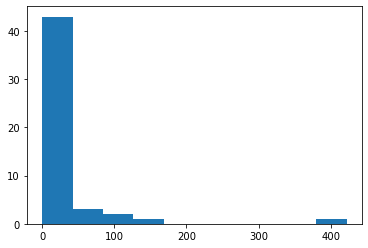

In [13]:
plt.hist(countsRBCL[0:50]); #counts for the first 100 RBCL columns

(array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 array([1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5]),
 <BarContainer object of 10 artists>)

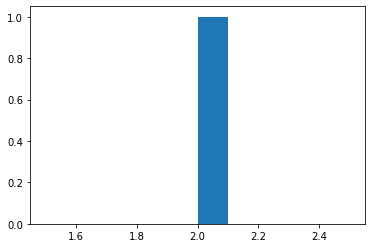

In [14]:
plt.hist(countsRBCL[0])

In [15]:
from sklearn.decomposition import PCA

PCA = PCA(svd_solver='full')
pca = PCA.fit_transform(justRBCL)
f = PCA.fit(justRBCL)


[0.44885771 0.12080896]


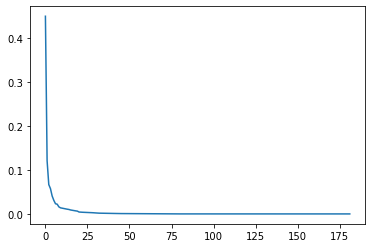

In [16]:
vars = f.explained_variance_ratio_
plt.plot(range(0,len(vars)), vars)
print(vars[0:2])

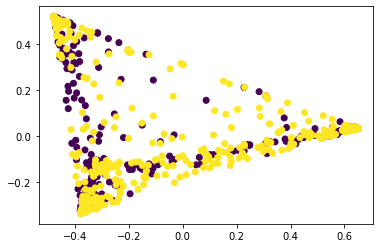

In [17]:
colors_vec = np.zeros(pca[:,0].shape[0])
colors_vec[(pca[:,0].shape[0] // 2):] = 1
plt.scatter(pca[:,0],pca[:,1],c=colors_vec)



[0.06658603 0.05740692]


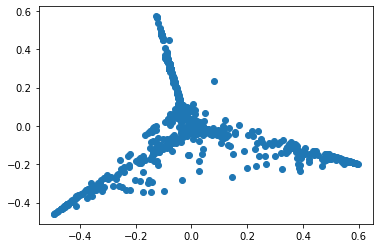

In [18]:
plt.scatter(pca[:,2],pca[:,3])
print(vars[2:4])

In [19]:
from sklearn.decomposition import PCA

PCA = PCA(svd_solver='full')
pca = PCA.fit_transform(justRBCL)
f = PCA.fit(justRBCL)


[0.44885771 0.12080896]


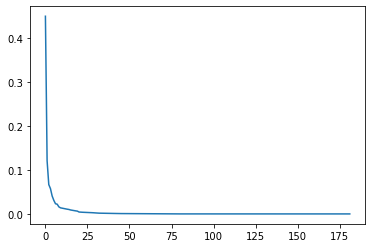

In [20]:
vars = f.explained_variance_ratio_
plt.plot(range(0,len(vars)), vars)
print(vars[0:2])

In [21]:
loc = ['OR' if str(i).startswith('SF') else 'SI' for i in df_all['UniqueID']]
len(loc)
my_colors = ['Orange' if i == 'OR' else 'Blue' for i in loc]
len(my_colors)

1382

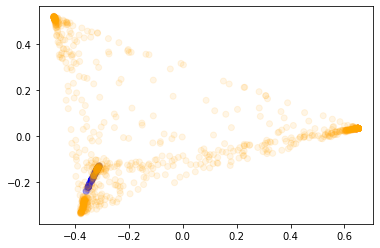

In [22]:
#color by Sky Islands (blue) vs FFAR(orange)
plt.scatter(pca[:,0],pca[:,1],c=my_colors,alpha=0.1);

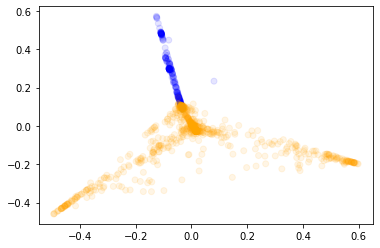

In [23]:
plt.scatter(pca[:,2],pca[:,3],c=my_colors,alpha=0.1)

In [24]:
import seaborn as sns
print(df_all['Genus'].unique())
#palette = sns.color_palette('Paired', 16) ## this only gives 12 unique colors then repeats so no good
#print(palette.as_hex())
#palette

[0 'Halictus' 'Lasioglossum' 'Svastra' 'Melissodes' 'Apis' 'Hylaeus'
 'Bombus' 'Peponapis' 'Xylocopa' 'Diadasia' 'Ceratina' 'Anthophora'
 'Ashmeadiella' 'Triepeolus']


In [25]:
print(df_all['Family'].unique())
palette2 = sns.color_palette(None, 3)
print(palette2.as_hex())
palette2

[0 'Halictidae' 'Apidae' 'Megachilidae']
['#1f77b4', '#ff7f0e', '#2ca02c']


[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313)]

In [26]:
genus_colors_dict = {'Bombus' : '#D2BBD7',
                     'Apis' : '#B98EB3',
                     'Megachile' : '#AA6F9F',
                     'Anthophora' : '#994F88',
                     'Agapostemon' : '#1964B0',
                     'Halictus' : '#518AC6',
                     'Lasioglossum' : '#7BB0DF',
                     'Svastra' : '#4DB264',
                     'Melissodes' : '#90C886',
                     'Hylaeus' : '#CAE1AC',
                     'Peponapis' : '#F7F057',
                     'Xylocopa' : '#F6C140',
                     'Diadasia' : '#F2932D', 
                     'Ceratina' : '#E8601C', 
                     'Ashmeadiella' : '#DB060B',
                     'Triepeolus' : '#71190D'}
fam_colors_dict = {'Apidae' : '#1f77b4',
                     'Megachilidae' : '#ff7f0e',
                     'Halictidae' : '#2ca02c'}
gen_cols = [genus_colors_dict[i] for i in df_all['Genus']]
fam_cols = [fam_colors_dict[i] for i in df_all['Family']]

KeyError: 0

In [ ]:
#color by bee genus
plt.scatter(pca[:,0],pca[:,1],c=gen_cols,alpha=0.9);

In [ ]:
#color by bee genus
plt.scatter(pca[:,2],pca[:,3],c=gen_cols,alpha=0.1);

In [ ]:
#color by bee family
plt.scatter(pca[:,0],pca[:,1],c=fam_cols);

In [ ]:
#color by bee genus
plt.scatter(pca[:,2],pca[:,3],c=fam_cols,alpha=0.3);

In [ ]:
print(df_all['Site'].unique())
len(df_all['Site'].unique())


k means

https://www.analyticsvidhya.com/blog/2021/04/k-means-clustering-simplified-in-python/ tutorial

In [ ]:
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn import *

In [ ]:
plt.scatter(pca[:,0],pca[:,1],c=my_colors,alpha=0.1)

In [ ]:
plt.scatter(pca[:,2],pca[:,3],c=my_colors,alpha=0.1)

In [ ]:
x = pca[:,0:2] 
x

In [ ]:
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='auto')
kmeans.fit(x)

In [ ]:
identified_clusters = kmeans.fit_predict(x)
identified_clusters

In [ ]:
from datascience import Table
data_with_clusters = Table().with_columns('pca1', pca[:,0], 'pca2', pca[:,1])
data_with_clusters['Clusters'] = identified_clusters 
data_with_clusters
plt.scatter(data_with_clusters['pca1'],data_with_clusters['pca2'],c=data_with_clusters['Clusters'],cmap='rainbow', alpha=0.5);

In [ ]:
x = pca[:,2:4] # 1t for rows and second for columns
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='auto')
kmeans.fit(x)
identified_clusters = kmeans.fit_predict(x)
data_with_clusters = Table().with_columns('pca3', pca[:,2], 'pca4', pca[:,3])
data_with_clusters['Clusters'] = identified_clusters 
data_with_clusters
plt.scatter(data_with_clusters['pca3'],data_with_clusters['pca4'],c=data_with_clusters['Clusters'],cmap='rainbow', alpha=0.5);

Support Vector Regression  
tutorial: https://medium.com/pursuitnotes/support-vector-regression-in-6-steps-with-python-c4569acd062d  
sci-kit doc: https://scikit-learn.org/stable/modules/svm.html#regression

In [ ]:
df_all